# IEEE-CIS Fraud Detection

This notebook works through the [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) Kaggle competition: a binary classification problem in which the goal is to predict whether an online card transaction is fraudulent. The dataset is provided by Vesta Corporation and contains 590,540 training transactions with 394 transaction-level features plus a further 41 identity features (merged via `TransactionID`). Most features are anonymised — `card1`–`card6`, `addr1`/`addr2`, and the `D`, `M`, and `V` series have no published meanings — which shapes the kind of feature engineering that's possible (frequency-based, behavioural, and time-derived) and largely rules out domain-specific transformations.

The underlying business problem is the everyday reality of every card issuer and payment processor: at production scale, the cost of blocking legitimate transactions (customer friction, abandoned purchases) and the cost of missing fraud (chargeback losses, brand damage) both compound quickly, and a useful model has to support a sensible operating threshold given those competing costs. For that reason, this notebook prioritises analyst-style reasoning alongside raw modelling performance — each modelling stage closes with a short *Findings* markdown cell explaining what changed, what improved, and what trade-offs were accepted (e.g., native categorical handling over an arbitrary encoding gain; honest reporting of null results from feature engineering experiments).

## Approach

The notebook proceeds in five stages:

1. **Exploratory data analysis** — fraud rate over time, distributional patterns by product code, transaction amount, and card network. The goal is to understand the structure of the data and identify both potential features and potential pitfalls before modelling.
2. **Baseline modelling** — fitting LightGBM with minimal preprocessing to establish a benchmark and surface methodological issues (notably the spurious top-feature ranking of `TransactionDT`, which is diagnosed and addressed).
3. **Modelling iterations** — switching to LightGBM's native categorical handling, engineering cyclic time features (`day_of_week`, `hour_of_day`), and adding frequency-encoded features for the highest-cardinality identifiers.
4. **Hyperparameter tuning** — Optuna-based search over LightGBM's capacity (`num_leaves`, `min_child_samples`) and regularisation (`subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`) parameters.
5. **Final model and submission** — refitting on the full training set with the tuned configuration, generating Kaggle submission output, and discussing the calibration between local validation AUC, held-out test AUC, and the Kaggle leaderboard score.

## Result

The final model — refit on the full training dataset with tuned hyperparameters — achieved:

- **Kaggle private leaderboard score: 0.916983**
- **Kaggle public leaderboard score: 0.939405**

These are the honest generalisation measures. The local validation AUC after hyperparameter tuning was meaningfully higher (around 0.93) due to the selection bias introduced by tuning hyperparameters and early stopping against the same validation set. That gap — and the reasoning behind it — is discussed in the relevant findings cells.


In [98]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna

## Loading Data and EDA

In [99]:
folder_path = 'datasets/'
train_identity = pd.read_csv(f'{folder_path}/train_identity.csv')
train_transaction = pd.read_csv(f'{folder_path}/train_transaction.csv')
test_identity = pd.read_csv(f'{folder_path}/test_identity.csv')
test_transaction = pd.read_csv(f'{folder_path}/test_transaction.csv')

train = pd.merge(train_transaction, train_identity, on="TransactionID", how="left")
test = pd.merge(test_transaction, test_identity, on="TransactionID", how="left")

In [ ]:
print(f'Train identity dataset has {train_identity.shape[0]} rows and {train_identity.shape[1]} columns.')
print(f'Train transaction dataset has {train_transaction.shape[0]} rows and {train_transaction.shape[1]} columns.')

Train identity dataset has 144233 rows and 41 columns.
Train transaction dataset has 590540 rows and 394 columns.


In [ ]:
print(f'Train dataset has {train.shape[0]} rows and {train.shape[1]} columns.')
print(f'Test dataset has {test.shape[0]} rows and {test.shape[1]} columns.')

Train dataset has 590540 rows and 434 columns.
Test dataset has 506691 rows and 433 columns.


In [ ]:
pd.set_option('display.max_columns', None)
train_transaction.head(100)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [ ]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
print(f'There are {train.isnull().any().sum()} columns in train dataset with missing values.')

There are 414 columns in train dataset with missing values.


In [ ]:
train[train['isFraud'] == 1].head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
203,2987203,1,89760,445.000,W,18268,583.0,150.0,visa,226.0,credit,251.0,87.0,NaN,NaN,aol.com,NaN,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,1.0,0.0,4.0,2.0,57.0,57.0,52.0,0.0,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN,NaN,374.0,NaN,NaN,NaN,M0,F,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,2987240,1,90193,37.098,C,13413,103.0,185.0,visa,137.0,credit,NaN,NaN,NaN,NaN,hotmail.com

In [ ]:
train.groupby('isFraud')['isFraud'].sum()

isFraud
0        0
1    20663
Name: isFraud, dtype: int64

In [ ]:
print(f'Fraudulent transaction rate: {train['isFraud'].mean():.4%}')

Fraudulent transaction rate: 3.4990%


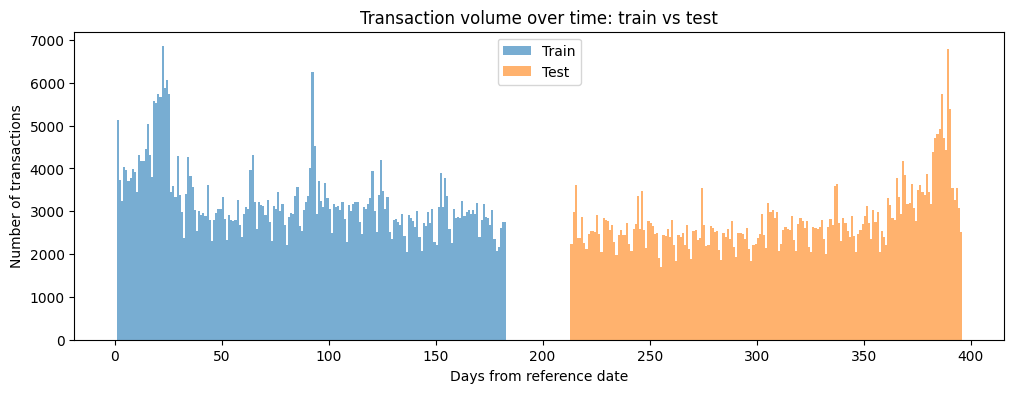

In [ ]:
plt.figure(figsize=(12, 4))

train_days = train['TransactionDT'] / 86400
test_days = test['TransactionDT'] / 86400

bins = np.arange(min(train_days.min(), test_days.min()),
                 max(train_days.max(), test_days.max()) + 1,
                 1)

plt.hist(train_days, bins=bins, alpha=0.6, label='Train')
plt.hist(test_days, bins=bins, alpha=0.6, label='Test')
plt.xlabel('Days from reference date')
plt.ylabel('Number of transactions')
plt.title('Transaction volume over time: train vs test')
plt.legend()
plt.show()

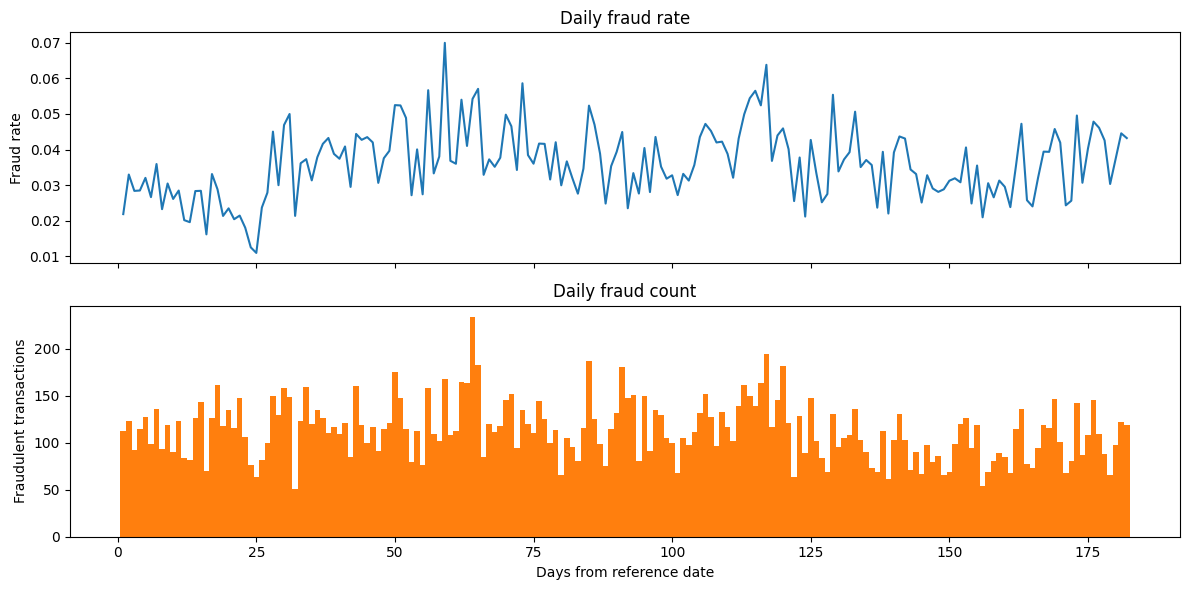

In [ ]:
daily_fraud = train.groupby(train['TransactionDT'] // 86400)['isFraud'].agg(['mean', 'sum', 'count'])
daily_fraud = daily_fraud.rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'transactions'})

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(daily_fraud.index, daily_fraud['fraud_rate'])
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Daily fraud rate')


axes[1].bar(daily_fraud.index, daily_fraud['fraud_count'], width=1.0, color='C1')
axes[1].set_ylabel('Fraudulent transactions')
axes[1].set_xlabel('Days from reference date')
axes[1].set_title('Daily fraud count')

plt.tight_layout()
plt.show()

## Patterns in fraud rate and volume over time

Daily fraud rate in the train set sits stably around 3.5%, with no significant trends, no isolated spikes well above baseline, and noise levels are consistent with normal day-to-day variance. The number of fraudulent transactions are generally proportionate to the total volume of transactions. At this point it also seems that fraud rate is independent of TransactionDT, as there is no significant variation in fraud hit rate throughout the training timeframe - at least at a day-to-day level.

Based on this information, we can infer that we do not need to give more recent time periods a greater weighting, and can treat each instance with an equal weighting, since fraud behaviour does not shift across the training period. It is also clear that raw TransactionDT or TransactionDT represented as days probably won't be relevant as a feature, however, further engineered features such as hour of day, day of week or seconds/minutes/hours since last transaction might carry significance instead.

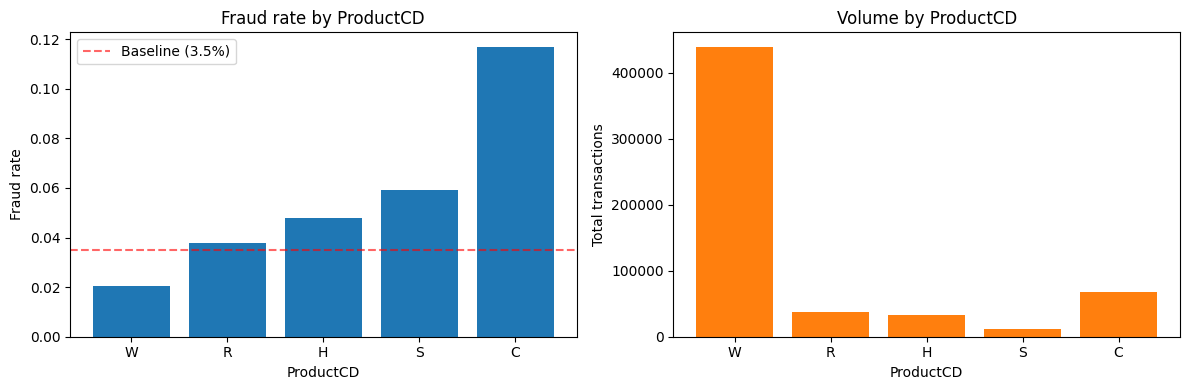

In [ ]:
fraud_productCD = train.groupby(train['ProductCD'])['isFraud'].agg(['mean', 'sum', 'count'])
fraud_productCD = fraud_productCD.rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'transactions'})

fraud_productCD_sorted = fraud_productCD.sort_values('fraud_rate')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(fraud_productCD_sorted.index, fraud_productCD_sorted['fraud_rate'])
axes[0].axhline(0.035, color='red', linestyle='--', alpha=0.6, label='Baseline (3.5%)')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Fraud rate by ProductCD')
axes[0].legend()

axes[1].bar(fraud_productCD_sorted.index, fraud_productCD_sorted['transactions'], color='C1')
axes[1].set_xlabel('ProductCD')
axes[1].set_ylabel('Total transactions')
axes[1].set_title('Volume by ProductCD')

plt.tight_layout()
plt.show()


In [ ]:
fraud_productCD['share_of_fraud'] = fraud_productCD['fraud_count'] / fraud_productCD['fraud_count'].sum()
fraud_productCD['share_of_volume'] = fraud_productCD['transactions'] / fraud_productCD['transactions'].sum()

fraud_productCD_sorted = fraud_productCD.sort_values('share_of_fraud', ascending=False)
fraud_productCD_sorted

,fraud_rate,fraud_count,transactions,share_of_fraud,share_of_volume
ProductCD,,,,,
W,0.020399,8969,439670,0.434061,0.744522
C,0.116873,8008,68519,0.387553,0.116028
H,0.047662,1574,33024,0.076175,0.055922
R,0.037826,1426,37699,0.069012,0.063838
S,0.058996,686,11628,0.033199,0.019690


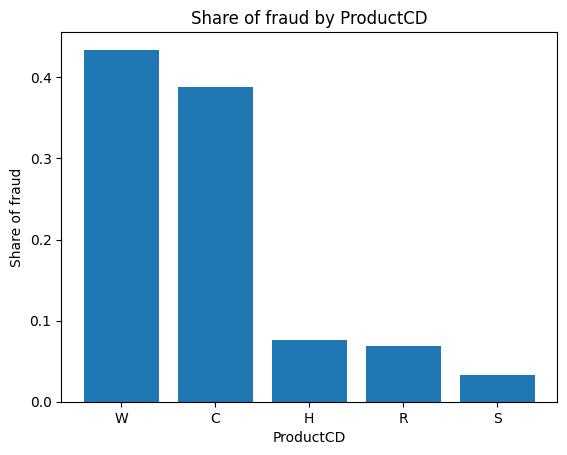

In [ ]:
plt.bar(fraud_productCD_sorted.index, fraud_productCD_sorted['share_of_fraud'])
plt.xlabel('ProductCD')
plt.ylabel('Share of fraud')
plt.title('Share of fraud by ProductCD')
plt.show()

## Patterns across product categories

In the graphs comparing ProductCD to fraud rate, volume, and share of fraud, two categories of products stand out in particular, W and C. 

Transactions categorised under W seem to hold a high share of total fraudulent transactions, however W also accounts for the majority of total transactions. In terms of fraud rate, only 2% of transactions categorised under W are fraudulent. Therefore, transactions involving W aren't inherently risky by this feature alone. 

If we look at transactions categorised under C, we can see that there is also a high share of total fraudulent transactions, at 38.8%. There is also a high fraud rate for C, at 11.7%, well above the total fraud rate of 3.5%. Transactions under C carry elevated risk demonstrated by the high fraud hit rate, which is roughly 3.3× the baseline fraud rate of 3.5%.

Categories H (4.8%), R (3.8%), and S (5.9%) all show fraud rates that are higher than the average fraud rate of 3.5%, however they also contribute to the smallest share of fraud (around 17% combined). It seems unlikely that these categories will carry meaningful predictive weight on their own, however they may still contribute in combination with other features.

ProductCD seems to be an important feature for this model, especially for transactions that are categorised under C. These payments warrant more aggressive rules when monitoring future customer transactions. Payments involving W in isolation aren't inherently risky, but should still be monitored, especially if they are occurring at a greater velocity than a customer's usual spending habit.  

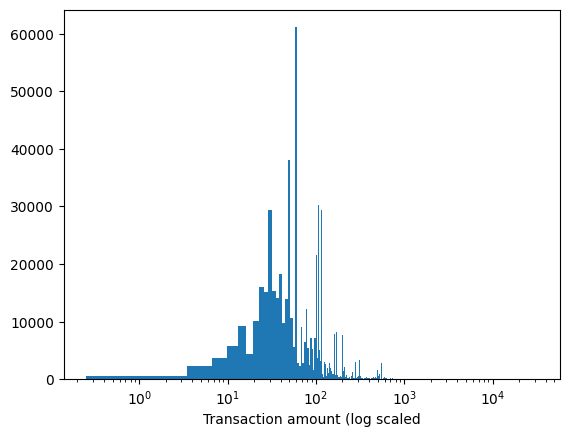

In [ ]:
plt.hist(train['TransactionAmt'], bins=10000)
plt.xscale('log')
plt.xlabel('Transaction amount (log scaled')
plt.show()

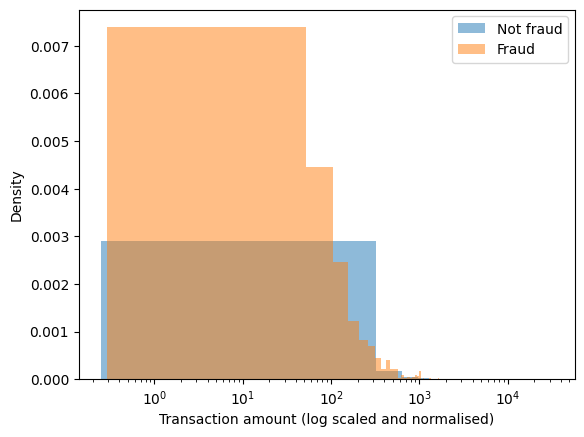

In [ ]:
plt.hist(train[train['isFraud'] == 0]['TransactionAmt'], bins=100, alpha=0.5, label='Not fraud', density=True)
plt.hist(train[train['isFraud'] == 1]['TransactionAmt'], bins=100, alpha=0.5, label='Fraud', density=True)
plt.xscale('log')
plt.xlabel('Transaction amount (log scaled and normalised)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
train.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [ ]:
edges = [0, 10, 25, 50, 100, 200, 400, 1000, 5000, train['TransactionAmt'].max()]
train['amt_bucket'] = pd.cut(train['TransactionAmt'], bins=edges, include_lowest=True)
fraud_by_amt = train.groupby('amt_bucket')['isFraud'].agg(['mean', 'sum', 'count'])
fraud_by_amt = fraud_by_amt.rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'transactions'})

fraud_by_amt['share_of_fraud'] = fraud_by_amt['fraud_count'] / fraud_by_amt['fraud_count'].sum()
fraud_by_amt['share_of_volume'] = fraud_by_amt['transactions'] / fraud_by_amt['transactions'].sum()
fraud_by_amt

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/613352661.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['amt_bucket'] = pd.cut(train['TransactionAmt'], bins=edges, include_lowest=True)


,fraud_rate,fraud_count,transactions,share_of_fraud,share_of_volume
amt_bucket,,,,,
"(-0.001, 10.0]",0.077660,608,7829,0.029425,0.013257
"(10.0, 25.0]",0.059116,2542,43000,0.123022,0.072815
"(25.0, 50.0]",0.030469,4683,153695,0.226637,0.260262
"(50.0, 100.0]",0.029178,4788,164095,0.231719,0.277873
"(100.0, 200.0]",0.030451,3899,128041,0.188695,0.216820
"(200.0, 400.0]",0.040454,2459,60785,0.119005,0.102931
"(400.0, 1000.0]",0.058270,1505,25828,0.072836,0.043736
"(1000.0, 5000.0]",0.024555,178,7249,0.008614,0.012275
"(5000.0, 31937.391]",0.055556,1,18,0.000048,0.000030


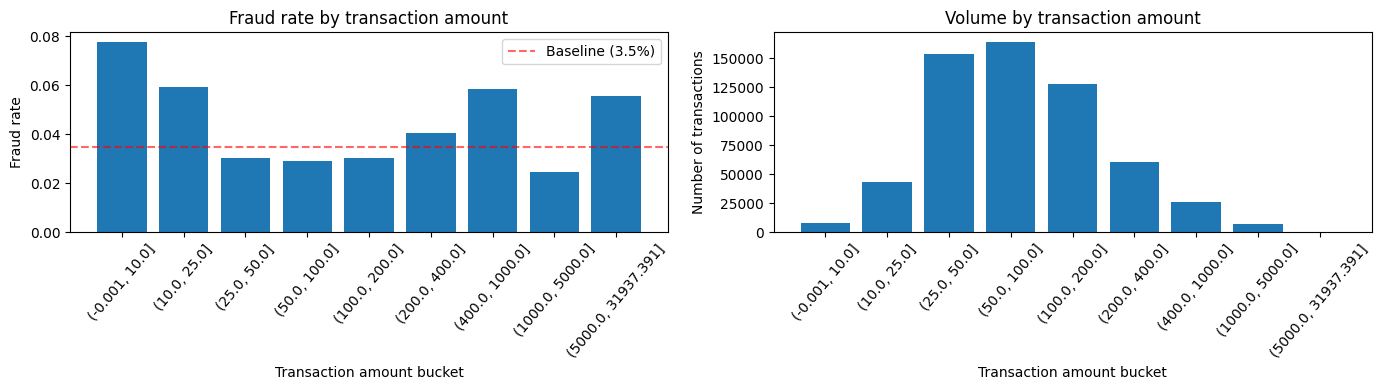

In [ ]:
labels = [str(x) for x in fraud_by_amt.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(labels, fraud_by_amt['fraud_rate'])
axes[0].axhline(0.035, color='red', linestyle='--', alpha=0.6, label='Baseline (3.5%)')
axes[0].set_xlabel('Transaction amount bucket')
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Fraud rate by transaction amount')
axes[0].tick_params(axis='x', rotation=50)
axes[0].legend()

axes[1].bar(labels, fraud_by_amt['transactions'])
axes[1].set_xlabel('Transaction amount bucket')
axes[1].set_ylabel('Number of transactions')
axes[1].set_title('Volume by transaction amount')
axes[1].tick_params(axis='x', rotation=50)

plt.tight_layout()
plt.show()

## Patterns across transaction amounts

By looking at the Fraud by Transaction Amount graph, there is a clear U-shaped distribution. Fraud rates for low value transactions (\$0-\$10 at 7.7% and \$10-\$25 at 5.9%) and higher value transactions (\$400-\$1000 at 5.8%) are clearly elevated by 1.6-2.2× the baseline fraud rate. Transactions that are between \$25 to \$400 sit around the baseline rate of fraud or lower. The \$1000-\$5000 bucket drops significantly to 2.5%, likely due to additional verification requirements such as 3DS. Transactions above \$5000 are too statistically unreliable to draw conclusions from, as there are only 18 total transactions in this dataset that sit in that bucket. It is also worth noting that while transactions between \$25 to \$200 make up about 65% of all fraudulent transactions in this dataset, simply because that's where most transactions occur, fraudulent or not. 

This distribution indicates a pattern where low value transactions are performed to test or validate the card and higher value transactions are attempted to extract value from the card before it is blocked. From these graphs, we are unable to determine whether these transactions are performed in sequence, or if they are performed in isolation.

TransactionAmt is likely a useful feature for the model, but the relationship between TransactionAmt and fraud rate is non-monotonic, so typical linear models will struggle to capture it. Tree-based models can learn this U-shape, and engineering new features such as taking the log of TransactionAmt or bucketed amount categories can assist further. 

The observed pattern supports the implementation of two types of rules: detection rules for low value transactions (e.g. rules on multiple small charges within a short period of time) and tighter rules on payments between \$400-\$1000.

In [ ]:
fraud_card4 = train.groupby(train['card4'])['isFraud'].agg(['mean', 'sum', 'count'])
fraud_card4 = fraud_card4.rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'transactions'})

fraud_card4['share_of_fraud'] = fraud_card4['fraud_count'] / fraud_card4['fraud_count'].sum()
fraud_card4['share_of_volume'] = fraud_card4['transactions'] / fraud_card4['transactions'].sum()

fraud_card4 = fraud_card4.sort_values('fraud_rate', ascending=False)
fraud_card4

,fraud_rate,fraud_count,transactions,share_of_fraud,share_of_volume
card4,,,,,
discover,0.077282,514,6651,0.024925,0.011293
visa,0.034756,13373,384767,0.648482,0.653296
mastercard,0.034331,6496,189217,0.315003,0.321271
american express,0.028698,239,8328,0.011590,0.014140


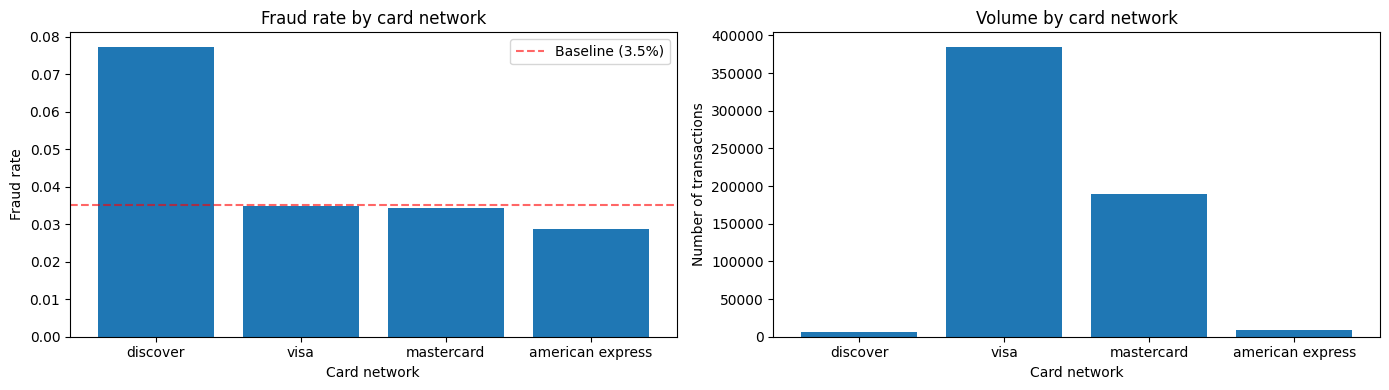

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(fraud_card4.index, fraud_card4['fraud_rate'])
axes[0].axhline(0.035, color='red', linestyle='--', alpha=0.6, label='Baseline (3.5%)')
axes[0].set_xlabel('Card network')
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Fraud rate by card network')
axes[0].legend()

axes[1].bar(fraud_card4.index, fraud_card4['transactions'])
axes[1].set_xlabel('Card network')
axes[1].set_ylabel('Number of transactions')
axes[1].set_title('Volume by card network')

plt.tight_layout()
plt.show()

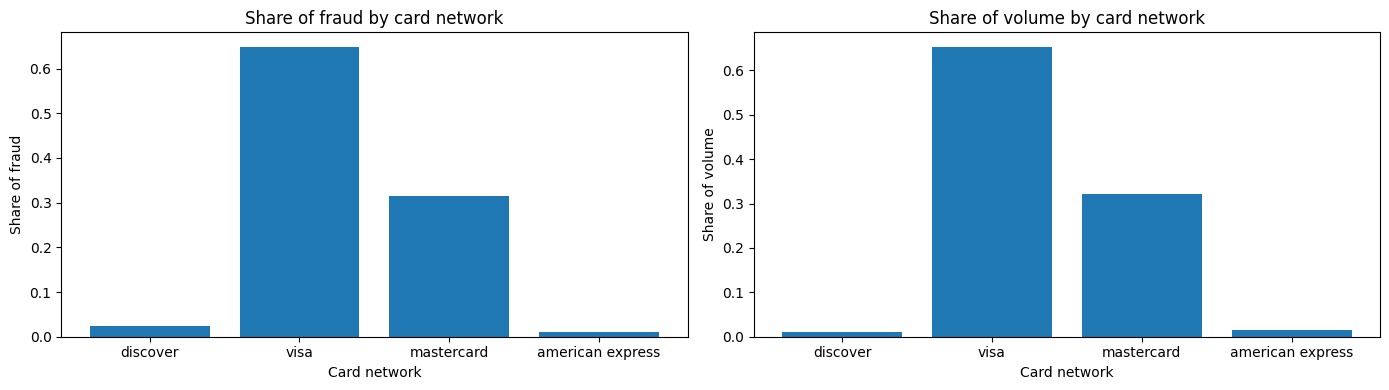

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(fraud_card4.index, fraud_card4['share_of_fraud'])
axes[0].set_xlabel('Card network')
axes[0].set_ylabel('Share of fraud')
axes[0].set_title('Share of fraud by card network')

axes[1].bar(fraud_card4.index, fraud_card4['share_of_volume'])
axes[1].set_xlabel('Card network')
axes[1].set_ylabel('Share of volume')
axes[1].set_title('Share of volume by card network')

plt.tight_layout()
plt.show()

## Patterns in card networks

Across Visa, Mastercard and American Express, fraud rates sit around the baseline rate of 3.5% (3.5%, 3.4%, 2.9% respectively). Discover is the exception, with a fraud rate of 7.7%. However, it only holds a 2.5% share in fraudulent transactions and a 1.1% share in total transations, so a rule based solely on Discover cards would have a modest impact with regards to fraud operations. Looking at all four networks, share of fraud closely scales with share in volume, indicating that the network alone carries little predictive signal in relation to fraud risk. 

card4 is unlikely to be a meaningful predictor on its own. It may still contribute when combined with other features, especially in the case of Discover cards. 

## Baseline model training

In [ ]:
train = train.sort_values('TransactionDT').reset_index(drop=True)

X = train.drop('isFraud', axis=1)
y = train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
print(f'Train rows: {len(X_train):,}, fraud rate: {y_train.mean():.4%}')
print(f'Test rows:   {len(X_val):,}, fraud rate: {y_val.mean():.4%}')
print(f'Train day range: {X_train["TransactionDT"].min()/86400:.1f} – {X_train["TransactionDT"].max()/86400:.1f}')
print(f'Val day range:   {X_val["TransactionDT"].min()/86400:.1f} – {X_val["TransactionDT"].max()/86400:.1f}')

Train rows: 472,432, fraud rate: 3.5135%
Test rows:   118,108, fraud rate: 3.4409%
Train day range: 1.0 – 141.1
Val day range:   141.1 – 183.0


In [ ]:
# Drop EDA artifacts and transaction identifiers
X_train = X_train.drop(['amt_bucket', 'TransactionID'], axis=1)
X_val = X_val.drop(['amt_bucket', 'TransactionID'], axis=1)

# Encode non-numerical columns into integers
for col in X_train.select_dtypes(include='object').columns:
    codes_train, uniques = pd.factorize(X_train[col])
    X_train[col] = codes_train
    X_val[col] = pd.Categorical(X_val[col], categories=uniques).codes

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/462971334.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include='object').columns:
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/462971334.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col] = pd.Categorical(X_val[col], categories=uniques).codes


In [ ]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,86400,68.50,0,13926,NaN,150.0,0,142.0,0,315.0,87.0,19.0,NaN,-1,-1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,0,0,0,0,0,0,-1,-1,-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,117.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,-1,-1,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,-1,-1,-1,-1,-1,NaN,-1,-1,-1,-1,-1,-1,-1,-1
1,86401,29.00,0,2755,404.0,150.0,1,102.0,0,325.0,87.0,NaN,NaN,0,-1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,Na

In [ ]:
model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

val_predictions = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_predictions)
print(f'Validation AUC: {auc:.4f}')

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.820890 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34557
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 431
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Validation AUC: 0.9013


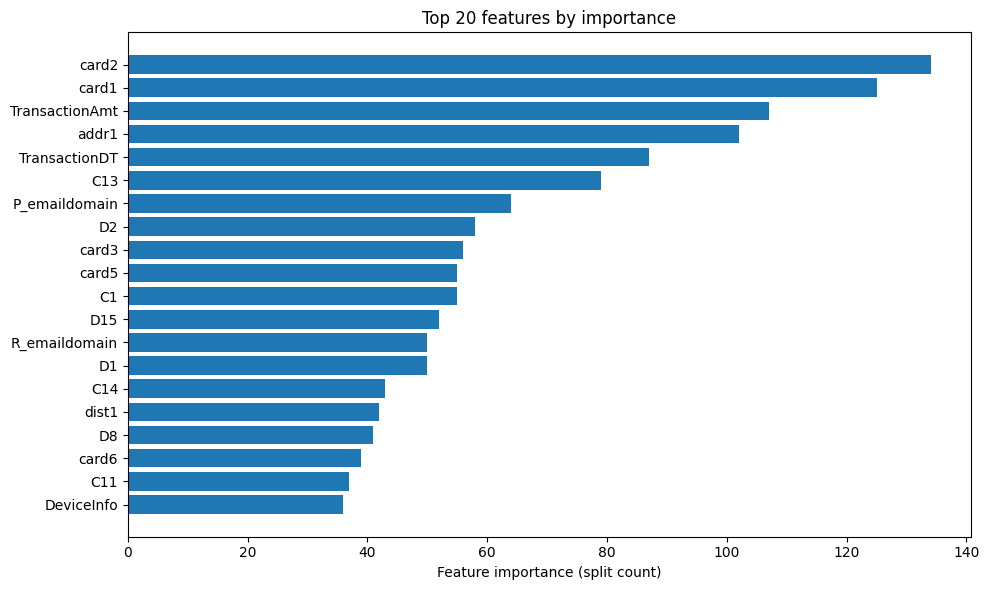

In [ ]:
importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top20 = importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20['feature'][::-1], top20['importance'][::-1])
plt.xlabel('Feature importance (split count)')
plt.title('Top 20 features by importance')
plt.tight_layout()
plt.show()

In [ ]:
importance.head(20)

,feature,importance
4,card2,134
3,card1,125
1,TransactionAmt,107
9,addr1,102
0,TransactionDT,87
27,C13,79
13,P_emaildomain,64
30,D2,58
5,card3,56
7,card5,55


### Findings from Initial Model Training

After reviewing the initial model, it seems the features that carry the importance are card2, card1, TransactionAmt, addr1 and TransactionDT. Intuitively, TransactionDT should not belong on this list, as seen from my earlier EDA, where it showed that rate rate for TransactionDT was time-insensitive. Every instance of TransactionDT in our validation and test sets would be greater than our training set so thresholds where the model splits at a certain TransactionDT would send all validation and test instances to one side, contributing nothing when attempting to infer new fraud instances. It would be necessary to test a model with TransactionDT removed. The expected outcome is that there will be little loss in AUC, with model performance holding similar or slightly better levels. After testing, it would be worthwhile to engineer more cyclical time based features such as day_of_week or hour_of_day.

## Dropping Transaction DT

In [ ]:
X_train = X_train.drop('TransactionDT', axis=1)
X_val   = X_val.drop('TransactionDT', axis=1)

In [ ]:
# refitting model after dropping TransactionDT
model.fit(X_train, y_train)

val_predictions = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_predictions)
print(f'Validation AUC without TransactionDT: {auc:.4f}')

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.658183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34302
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 430
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Validation AUC without TransactionDT: 0.9026


By dropping TransactionDT there was a minor increase in AUC, from 0.9013 to 0.9026. This shows that the model is barely affected by removing TransactionDT, and that by dropping TransactionDT, it will likely help future model performance as well. 

## Early Stopping

In [ ]:
# Renaming datasets and splitting original train into a 60/20/20 partition for training,
# early stopping validation, and final testing
train = train.sort_values('TransactionDT').reset_index(drop=True)
kaggle_test = test

X = train.drop('isFraud', axis=1)
y = train['isFraud']

X = X.drop(['amt_bucket', 'TransactionID', 'TransactionDT'], axis=1)

# split into 60/40, test and temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, shuffle=False)

# split 40 in half, val and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Encode non-numerical columns into integers
for col in X_train.select_dtypes(include='object').columns:
    codes_train, uniques = pd.factorize(X_train[col])
    X_train[col] = codes_train
    X_val[col] = pd.Categorical(X_val[col], categories=uniques).codes
    X_test[col] = pd.Categorical(X_test[col], categories=uniques).codes

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/255641149.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include='object').columns:
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/255641149.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col] = pd.Categorical(X_val[col], categories=uniques).codes
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/

In [ ]:
print(f'Train: {len(X_train):,} rows, fraud rate: {y_train.mean():.4%}')
print(f'Val:   {len(X_val):,} rows, fraud rate: {y_val.mean():.4%}')
print(f'Test:  {len(X_test):,} rows, fraud rate: {y_test.mean():.4%}')

Train: 354,324 rows, fraud rate: 3.3833%
Val:   118,108 rows, fraud rate: 3.9041%
Test:  118,108 rows, fraud rate: 3.4409%


In [ ]:
# Baseline on the 60/20/20 split (no hyperparameter changes)
baseline_model = lgb.LGBMClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_val, baseline_model.predict_proba(X_val)[:, 1])
print(f'Baseline val AUC (new split):    {baseline_auc:.4f}')

[LightGBM] [Info] Number of positive: 11988, number of negative: 342336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.457603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34429
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 429
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033833 -> initscore=-3.351887
[LightGBM] [Info] Start training from score -3.351887
Baseline val AUC (new split):    0.9132


In [ ]:
# Tuned model on the same split
tuned_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
tuned_model.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='auc',
                callbacks=[lgb.early_stopping(50)])
tuned_auc = roc_auc_score(y_val, tuned_model.predict_proba(X_val)[:, 1])
print(f'Tuned val AUC (new split):       {tuned_auc:.4f}')

[LightGBM] [Info] Number of positive: 11988, number of negative: 342336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.462971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34429
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 429
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033833 -> initscore=-3.351887
[LightGBM] [Info] Start training from score -3.351887
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[653]	valid_0's auc: 0.925498	valid_0's binary_logloss: 0.0908828
Tuned val AUC (new split):       0.9255


By increasing the maximum number of trees (n_estimators), the model ahs more capacity to fit the training data. To guard against overfitting, we monitor AUC against a held-out evaluation set after each boosting round. If validation AUC fails to improve for 50 consecutive rounds (under the early stopping parameter), training stops early and the model rolls back to the iteration with the highest validation AUC. 

## Native categorical encoding

In [ ]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f'{len(cat_cols)} categorical columns identified')

31 categorical columns identified


/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1042884617.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


In [ ]:
# Rebuilt training, evaluation and test sets
train = train.sort_values('TransactionDT').reset_index(drop=True)
kaggle_test = test

X = train.drop('isFraud', axis=1)
y = train['isFraud']

X = X.drop(['amt_bucket', 'TransactionID', 'TransactionDT'], axis=1)

# split into 60/40, test and temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, shuffle=False)

# split 40 in half, val and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Convert to pandas Categorical, using train's unique values as the canonical set
for col in cat_cols:
    train_categories = X_train[col].astype('category').cat.categories
    X_train[col] = pd.Categorical(X_train[col], categories=train_categories)
    X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories)
    X_test[col]  = pd.Categorical(X_test[col],  categories=train_categories)

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1543956862.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1543956862.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[col]  = pd.Categorical(X_test[col],  categories=train_categories)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1543956862.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories

In [ ]:
cat_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
cat_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(50)])

cat_auc = roc_auc_score(y_val, cat_model.predict_proba(X_val)[:, 1])
print(f'AUC with native categorical handling: {cat_auc:.4f}')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 11988, number of negative: 342336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.436141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34754
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 429
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033833 -> initscore=-3.351887
[LightGBM] [Info] Start training from score -3.351887
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[459]	valid_0's auc: 0.92018	valid_0's binary_logloss: 0.0937315
AUC with native categorical handling: 0.9202


### Findings: native categorical encoding

Rather than encoding categorical features into integers, they have instead been passed directly to the model as categorical columns. LightGBM has the native capacity to process categorical features, provided we tell the model which columns are categorical. The reasoning behind this change is to ensure the model does not infer signal from the arbitrary order of encoded integers.

Take the `card4` column as an example: factorisation assigns {visa, amex, mastercard, discover} to {1, 2, 3, 4} respectively. This leads the model to consider comparisons such as `card4 < 2.5` — but the ordering should not matter here. "Visa" isn't semantically less than "mastercard", even though the encoding forces a comparison as if it were. Native categorical handling splits via set-partition (e.g., `card4 in {visa, amex}` vs `in {mastercard, discover}`), which is the correct comparison for an unordered column.

**Outcomes:**
- Validation AUC moved from 0.9255 → 0.9202, a decrease of 0.0053.

The factorised-integer model achieved its slightly higher AUC by exploiting how the data was encoded (the arbitrary ordering of categories) rather than a property of the data itself. Native categorical handling is the correct way to process unordered categorical features in this dataset, and the small validation-AUC concession is an acceptable trade for stronger model semantics — particularly in a production fraud context, where new categories (devices or email domains) emerge over time and the dtype-correct approach generalises more reliably.


## Featuring engineering using TransactionDT

In [ ]:
# Engineer time-based features from TransactionDT
train['day_of_week'] = (train['TransactionDT'] // 86400) % 7
train['hour_of_day'] = (train['TransactionDT'] // 3600) % 24

In [ ]:
# Renaming datasets and splitting original train into a 60/20/20 partition for training,
# early stopping validation, and final testing
train = train.sort_values('TransactionDT').reset_index(drop=True)
kaggle_test = test

X = train.drop('isFraud', axis=1)
y = train['isFraud']

X = X.drop(['amt_bucket', 'TransactionID', 'TransactionDT'], axis=1)

# split into 60/40, test and temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, shuffle=False)

# split 40 in half, val and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Convert to pandas Categorical, using train's unique values as the canonical set
for col in cat_cols:
    train_categories = X_train[col].astype('category').cat.categories
    X_train[col] = pd.Categorical(X_train[col], categories=train_categories)
    X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories)
    X_test[col]  = pd.Categorical(X_test[col],  categories=train_categories)

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/3359304906.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/3359304906.py:22: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[col]  = pd.Categorical(X_test[col],  categories=train_categories)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/3359304906.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val[col]   = pd.Categorical(X_val[col],   categories=train_categories

In [ ]:
model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(50)])

auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print(f'AUC with engineered time features: {auc:.4f}')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 11988, number of negative: 342336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.426824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34796
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 431
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033833 -> initscore=-3.351887
[LightGBM] [Info] Start training from score -3.351887
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[473]	valid_0's auc: 0.921047	valid_0's binary_logloss: 0.0924758
AUC with engineered time features: 0.9210


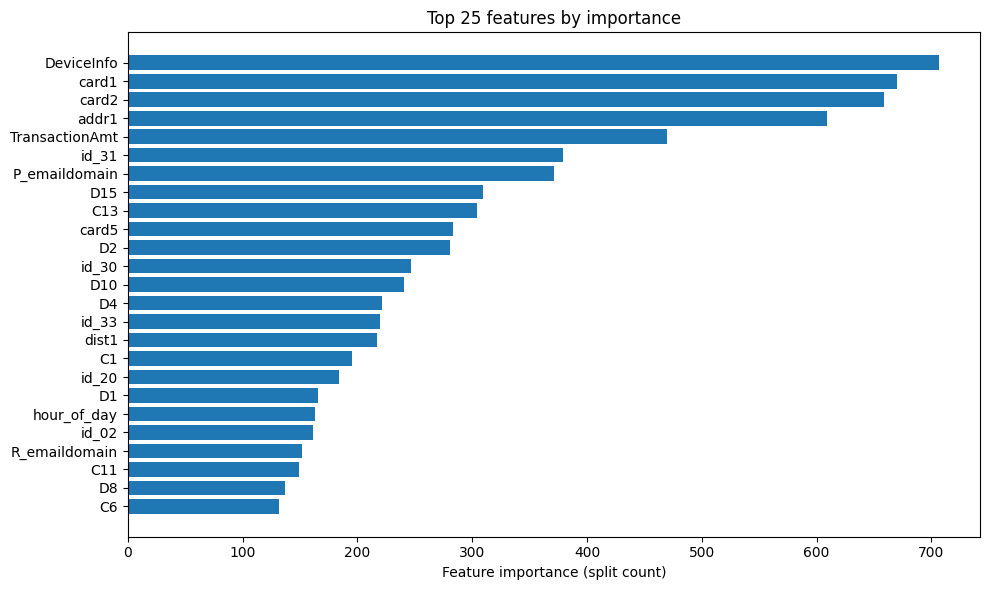

In [ ]:
importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top25 = importance.head(25)

plt.figure(figsize=(10, 6))
plt.barh(top25['feature'][::-1], top25['importance'][::-1])
plt.xlabel('Feature importance (split count)')
plt.title('Top 25 features by importance')
plt.tight_layout()
plt.show()

### Findings: engineered time features

Engineered `day_of_week` and `hour_of_day` from `TransactionDT`, kept as numeric integers rather than categorical (an initial categorical attempt produced a small regression to 0.9189, confirming ordinal treatment was correct for naturally ordered features).

**Outcomes:**
- Validation AUC moved from 0.9202 → 0.9210 (+0.0008), which sits within the model's run-to-run noise band — effectively a null result on AUC.
- `hour_of_day` ranks 20th in feature importance — present in the rankings but with marginal contribution. The time-of-day signal exists, but is largely redundant with patterns the model has already extracted from categorical and frequency-encoded features. Behavioral rhythm inferred from card and address identifiers seem to already captures most of what `hour_of_day` would otherwise add.
- `day_of_week` does not appear in the top 20 — weekday patterns are weaker still, or fully absorbed by other features.

The features were retained because they are interpretable, low-cost, and resilient to drift in other features. In a production fraud system, explicit time-of-day features support analyst review of flagged transactions ("flagged partly because it occurred at 3:47 AM") even when their marginal contribution to model AUC is small.


### Frequency encoding for high cardinality columns

In [ ]:
train['card1'].value_counts()

card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
         ...  
7236         1
17972        1
13166        1
8767         1
18038        1
Name: count, Length: 13553, dtype: int64

In [ ]:
high_card_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

# Frequency map for training data only
for col in high_card_cols:
    freq_map = X_train[col].value_counts()

    # Apply map to all sets
    new_col = f'{col}_freq'
    X_train[new_col] = X_train[col].map(freq_map).fillna(0).astype(int)
    X_val[new_col] = X_val[col].map(freq_map).fillna(0).astype(int)
    X_test[new_col] = X_test[col].map(freq_map).fillna(0).astype(int)

In [ ]:
# Retrain model
model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(50)])

auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print(f'AUC after frequency encoding: {auc:.4f}')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 11988, number of negative: 342336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.323175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35862
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 443
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033833 -> initscore=-3.351887
[LightGBM] [Info] Start training from score -3.351887
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[438]	valid_0's auc: 0.925105	valid_0's binary_logloss: 0.0922854
AUC after frequency encoding: 0.9251


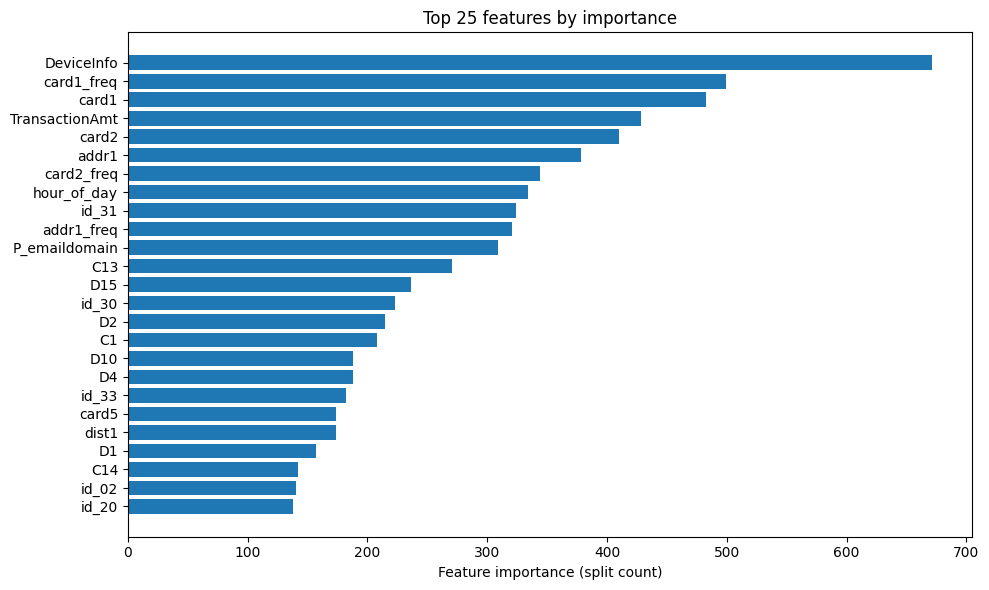

In [ ]:
importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top25 = importance.head(25)

plt.figure(figsize=(10, 6))
plt.barh(top25['feature'][::-1], top25['importance'][::-1])
plt.xlabel('Feature importance (split count)')
plt.title('Top 25 features by importance')
plt.tight_layout()
plt.show()

### Findings: frequency encoding for high-cardinality columns

Added frequency-encoded companion features for 12 high-cardinality categorical columns (`card1`, `card2`, `card3`, `card5`, `addr1`, `addr2`, `P_emaildomain`, `R_emaildomain`, `id_30`, `id_31`, `id_33`, `DeviceInfo`). For each column, a new `_freq` feature contains the count of that category's occurrences in training. The original categorical column was kept — the model now has access to both the categorical identity (set-partition splits) and the numeric rarity (threshold splits).

The motivation is that LightGBM's native categorical handling becomes increasingly noisy at very high cardinality. For a column like `card1` with over 13,000 unique values, splits made on using that column don't generalise reliably. A continuous frequency column lets the model access the cardinality signal — "rare card vs common card" — through a single, stable threshold split instead of having to rediscover it via categorical partitions.

The frequency map was computed from training data only — categories appearing in validation or test that were unseen in training receive a frequency of 0. This is the conservative choice for a time-based split: using the combined dataset to compute frequencies would not technically leak the target (the count doesn't depend on `isFraud`), but the train-only approach generalises more honestly across time.

**Outcomes:**
- Validation AUC moved from 0.9210 → 0.9251 (+0.0041) — outside the model's run-to-run noise band, so a real if modest gain.
- `card1_freq`, `card2_freq`, and `addr1_freq` both appear in the top 10 by importance, confirming that using rarity can return meaningful fraud signals.

In a production system, rarity is one of the most robust fraud signals — compromised cards often transact from new addresses, fraudulent accounts often use newly created email domains, and bot-driven fraud often surfaces previously-unseen `DeviceInfo` strings. Frequency encoding makes this signal directly accessible to the model rather than relying on the tree to rediscover it through complex categorical splits. The technique also continues to work as the categorical landscape evolves over time — each retraining cycle updates the frequency map naturally.


## Hyperparameter tuning with Optuna

In [ ]:
def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'random_state': 42,
        'verbose': -1,  # suppress LightGBM warnings during HPO
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq': 1,  # required for subsample to actually take effect
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(50, verbose=False)])
    
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Best AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')


[I 2026-06-04 23:20:39,726] A new study created in memory with name: no-name-5e42692f-df39-4264-85cc-a24af36ad4a7
Best trial: 0. Best value: 0.92622:   2%|▏         | 1/50 [01:00<49:47, 60.96s/it]

[I 2026-06-04 23:21:40,697] Trial 0 finished with value: 0.9262199287860285 and parameters: {'num_leaves': 115, 'min_child_samples': 477, 'subsample': 0.892797576724562, 'colsample_bytree': 0.7993292420985183, 'reg_alpha': 0.004207988669606638, 'reg_lambda': 0.004207053950287938}. Best is trial 0 with value: 0.9262199287860285.


Best trial: 0. Best value: 0.92622:   4%|▍         | 2/50 [01:52<44:11, 55.23s/it]

[I 2026-06-04 23:22:31,927] Trial 1 finished with value: 0.9195016255248384 and parameters: {'num_leaves': 44, 'min_child_samples': 436, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8540362888980227, 'reg_alpha': 0.0012087541473056963, 'reg_lambda': 7.579479953348009}. Best is trial 0 with value: 0.9262199287860285.


Best trial: 2. Best value: 0.930911:   6%|▌         | 3/50 [02:32<38:02, 48.56s/it]

...

[I 2026-06-04 23:51:18,210] Trial 47 finished with value: 0.9329453078253653 and parameters: {'num_leaves': 222, 'min_child_samples': 27, 'subsample': 0.813860485784344, 'colsample_bytree': 0.5025391434583747, 'reg_alpha': 0.6162876764252654, 'reg_lambda': 0.018090915717594993}. Best is trial 45 with value: 0.9331015921404648.


Best trial: 48. Best value: 0.933184:  98%|█████████▊| 49/50 [31:15<00:36, 36.57s/it]

[I 2026-06-04 23:51:55,610] Trial 48 finished with value: 0.933184474094853 and parameters: {'num_leaves': 221, 'min_child_samples': 44, 'subsample': 0.8468374983029202, 'colsample_bytree': 0.503237310339125, 'reg_alpha': 0.5294491522023345, 'reg_lambda': 0.0057737993357805896}. Best is trial 48 with value: 0.933184474094853.


Best trial: 48. Best value: 0.933184: 100%|██████████| 50/50 [31:54<00:00, 38.28s/it]

[I 2026-06-04 23:52:33,929] Trial 49 finished with value: 0.9309113378495142 and parameters: {'num_leaves': 220, 'min_child_samples': 49, 'subsample': 0.8599573022932749, 'colsample_bytree': 0.5357468467434264, 'reg_alpha': 2.726262692969076, 'reg_lambda': 0.005209980179340248}. Best is trial 48 with value: 0.933184474094853.
Best AUC: 0.9332
Best params: {'num_leaves': 221, 'min_child_samples': 44, 'subsample': 0.8468374983029202, 'colsample_bytree': 0.503237310339125, 'reg_alpha': 0.5294491522023345, 'reg_lambda': 0.0057737993357805896}


In [ ]:
final_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    **study.best_params
)

final_model.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='auc',
                callbacks=[lgb.early_stopping(50)])

val_auc = roc_auc_score(y_val, final_model.predict_proba(X_val)[:, 1])
print(f'Final val AUC: {val_auc:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[138]	valid_0's auc: 0.934172	valid_0's binary_logloss: 0.0906611
Final val AUC: 0.9342


In [ ]:
test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f'Held-out test AUC: {test_auc:.4f}')

Held-out test AUC: 0.9038


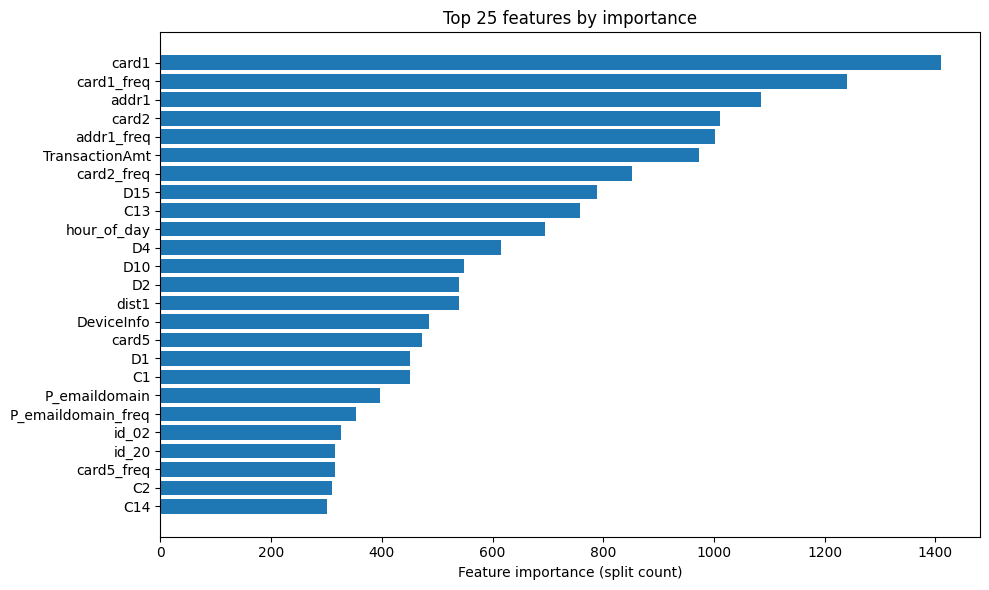

In [ ]:
importance = pd.DataFrame({
    'feature': final_model.feature_name_,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

top25 = importance.head(25)

plt.figure(figsize=(10, 6))
plt.barh(top25['feature'][::-1], top25['importance'][::-1])
plt.xlabel('Feature importance (split count)')
plt.title('Top 25 features by importance')
plt.tight_layout()
plt.show()

### Findings: hyperparameter tuning with Optuna

Used Optuna with the TPE sampler to search six LightGBM hyperparameters across 50 trials. TPE weighs its sampling towards parameter combinations that previous trials suggest are promising — for a six-dimensional search, 50 guided trials outperform 50 random points by a meaningful margin.

**Outcomes:**
- Validation AUC moved from 0.9251 → 0.9342 (+0.0091)

**Caveat on validation-based HPO.** Tuning to maximise validation AUC introduces selection bias: with 50 trials of guided search, the chosen configuration is partially fit to the specific noise structure of the validation set. The val AUC of 0.9342 is therefore an upward-biased estimate of true generalisation — the true measures are the held-out test set (untouched throughout HPO and early stopping) and the Kaggle private leaderboard.


## A Note on User IDs
In this competition dataset, a lot of features were obscured and censored, due to confidentiality requirements from the dataset provider. One piece of information that would be present in production but not in this dataset would be a user ID. A user ID could be synthesised using probable user identifiers such as card1, addr1 and D1. Once we have a user ID, we can then use it to aggregate across users to determine cardholder specific information such as a user's typical spend, spending variability, transaction frequency and device diversity. This would change our perspective of the problem - as instead of viewing each transaction in isolation, we would then be looking at a whole user's activity and be on the hunt for bad actors. 

However, in a production fraud system, a stable user id and aggregate features would already exist. For the purposes of this notebook (focusing on patterns and code that would translate to production) this synthesis step has been omitted.

## Final model: full-data refit and Kaggle submission

The model trained so far used the 60% training partition with the remaining 40% reserved for early stopping (validation) and held-out testing. For the actual Kaggle submission, we refit the tuned configuration on the **entire** training set — there's no point holding data out at submission time, since Kaggle's leaderboard provides the honest test. Without a validation set we lose early stopping, so `n_estimators` is fixed manually, scaled up from `final_model.best_iteration_` to account for the larger training set.

In [97]:
# Sort and build X and y from the entire training set
train = train.sort_values('TransactionDT').reset_index(drop=True)

X = train.drop(['isFraud', 'TransactionID', 'TransactionDT', 'amt_bucket'], axis=1)
y = train['isFraud']

# Categorical columns: convert to pd.Categorical using train's category set
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    categories = X[col].astype('category').cat.categories
    X[col] = pd.Categorical(X[col], categories=categories)

high_card_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
                  'P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

freq_maps = {}
for col in high_card_cols:
    freq_maps[col] = X[col].value_counts()
    X[f'{col}_freq'] = X[col].map(freq_maps[col]).fillna(0).astype(int)

print(f'X shape: {X.shape}, fraud rate: {y.mean():.4%}')

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/4213891221.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


X shape: (590540, 445), fraud rate: 3.4990%


/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/4213891221.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f'{col}_freq'] = X[col].map(freq_maps[col]).fillna(0).astype(int)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/4213891221.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f'{col}_freq'] = X[col].map(freq_maps[col]).fillna(0).astype(int)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/4213891221.py:19: PerformanceWarning: DataFrame is highly fragmented.  This

In [94]:
# No validation set in full-data training, so n_estimators is set manually.
# Scale up from final_model.best_iteration_ proportionally to the larger training set.
n_estimators_final = int(final_model.best_iteration_ * 1.6)
print(f'Training submission model with n_estimators = {n_estimators_final}')

submission_model = lgb.LGBMClassifier(
    n_estimators=n_estimators_final,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    **{k: v for k, v in study.best_params.items() if k not in ('n_estimators', 'learning_rate')}
)
submission_model.fit(X, y)
print('Submission model trained.')

Training submission model with n_estimators = 220
Submission model trained.


In [95]:
# IEEE quirk: test_identity uses id-XX (hyphens) while train_identity uses id_XX (underscores).
# Rename for consistency so the column sets line up.
kaggle_test.columns = [c.replace('-', '_') if c.startswith('id-') else c for c in kaggle_test.columns]

# Engineered time features must be added to kaggle_test too
kaggle_test['day_of_week'] = (kaggle_test['TransactionDT'] // 86400) % 7
kaggle_test['hour_of_day'] = (kaggle_test['TransactionDT'] // 3600) % 24

# Build X_kaggle with the same column set as X
X_kaggle = kaggle_test.drop(['TransactionID', 'TransactionDT'], axis=1)

# Convert categoricals using train's categories (unseen values become NaN — handled by LightGBM)
for col in cat_cols:
    X_kaggle[col] = pd.Categorical(X_kaggle[col], categories=X[col].cat.categories)

# Apply train-derived frequency maps (unseen categories get frequency 0)
for col in high_card_cols:
    X_kaggle[f'{col}_freq'] = X_kaggle[col].map(freq_maps[col]).fillna(0).astype(int)

# Ensure column order matches X (LightGBM expects identical column ordering)
X_kaggle = X_kaggle[X.columns]

print(f'X_kaggle shape: {X_kaggle.shape}')

/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1100643821.py:14: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_kaggle[col] = pd.Categorical(X_kaggle[col], categories=X[col].cat.categories)


X_kaggle shape: (506691, 445)


/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1100643821.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_kaggle[f'{col}_freq'] = X_kaggle[col].map(freq_maps[col]).fillna(0).astype(int)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1100643821.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_kaggle[f'{col}_freq'] = X_kaggle[col].map(freq_maps[col]).fillna(0).astype(int)
/var/folders/ns/470lr23x7jn936f1_pv4sgbc0000gn/T/ipykernel_23061/1100643821.py:18: PerformanceWarning: DataFrame

In [96]:
# Predict fraud probability for each test transaction
kaggle_predictions = submission_model.predict_proba(X_kaggle)[:, 1]

submission = pd.DataFrame({
    'TransactionID': kaggle_test['TransactionID'],
    'isFraud': kaggle_predictions
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {len(submission):,} predictions')
submission.head()

Submission saved: 506,691 predictions


,TransactionID,isFraud
0,3663549,0.000956
1,3663550,0.001582
2,3663551,0.002355
3,3663552,0.002355
4,3663553,0.001144


### Findings: final model on Kaggle

The full-data refit was submitted to Kaggle, with the following leaderboard results:

- **Kaggle private leaderboard score: 0.9170**
- **Kaggle public leaderboard score: 0.9394**

The private score is the meaningful one. Kaggle's private test set represents the model's performance on transactions it has truly never seen.

**Comparing with local AUC measures:**

- Local validation AUC (used for early stopping and HPO): 0.9342
- Local held-out test AUC: 0.9038
- Kaggle private leaderboard: 0.9170

The validation vs test gap (0.9342 → 0.9038, a drop of roughly 3 percentage points) is the most important number in this comparison. It is a way to quantify the selection bias from hyperparameter tuning: tuning hyperparameters and early stopping against the validation set produced a configuration that fit that specific sample's noise structure, inflating val AUC by ~3pp relative to a clean held-out estimate. This is exactly the bias the HPO findings cell warned about — and quantifying it directly is more useful than the abstract warning.

The test-vs-Kaggle gap (0.9038 → 0.9170) runs the opposite direction, with two effects working in the submission model's favour:

1. **The submission model was refit on the full training data** (train + val + test combined), whereas the local test AUC was measured on the 60%-train `final_model`. The extra training data gives the submission model a real performance edge — likely most of this gap.
2. **Kaggle's private test set is much larger** (~506K rows vs ~118K local test), so its AUC is statistically more precise. The local 0.9038 has a non-trivial standard error at that sample size and fraud rate, while Kaggle's score is effectively noise-free.

**The production takeaway:** the ~3pp val-to-test gap is the single most useful number for production planning. It represents how much the model's apparent performance on training-adjacent data exceeds its true generalisation. In a production fraud system, the relevant analogue is the gap between "AUC observed during retraining" and "AUC observed on next week's transactions" — and 3pp is a sensible baseline expectation, before further distributional drift compounds on top.